In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
# https://lownoisefactory.com/product/lnf-nano9m/
# length = 460E-3 # 460 mm0
area = 0.0509E-6 # 30 AWG = 0.0509 mm2

# krinner
l_50K = 20E-2 
l_4K = 29E-2 
l_Still = 25E-2 
l_CP = 17E-2 
l_MXC = 14E-2 

# Thermal Conductivity

In [3]:
# Calculate the heat load from 50K to 4K for a single strand of a TwP Cu wire that is used to bias the HEMT.

In [4]:
# conductivity, K
# https://trc.nist.gov/cryogenics/materials/OFHC%20Copper/OFHC_Copper_rev1.htm

def conductivity(T):
    # Units = W/m.K
    # Assuming RRR = 50
    a = 1.8743
    b = -0.41538
    c = -0.6018
    d = 0.13294
    e = 0.26426
    f = -0.0219
    g = -0.051276	
    h = 0.0014871	
    i = 0.003723
    
    # Assuming RRR = 100
    # a = 2.2154
    # b = -0.47461
    # c = -0.88068
    # d = 0.13871	
    # e = 0.29505
    # f = -0.02043
    # g = -0.04831
    # h = 0.001281
    # i = 0.003207

    k = 10**((a + c*T**0.5 + e*T + g*T**1.5 + i*T**2) / (1 + b*T**0.5 + d*T + f*T**1.5 + h*T**2))
    
    return k

In [5]:
import numpy as np
temp = np.linspace(0,300)
values = conductivity(temp)

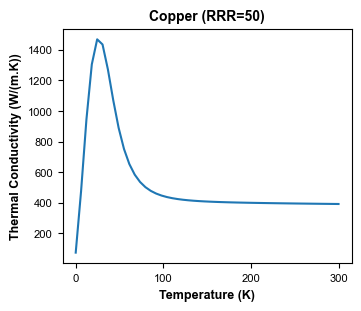

In [6]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


# Similar to graph in Fig. 5 of 2017greenConnectionRefrigerationSuperconducting (RRR=50)
ax.plot(temp,values)
ax.set_title("Copper (RRR=50)", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(m.K))', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

plt.savefig(f"./cu_k.png",dpi=600)
plt.show()

In [7]:
# Calculate the passive heat load (Watts) flowing from 50K to 4K
# using integration

from scipy.integrate import quad
import math

In [8]:
# Integrate f(x) from 50K to 4K
result, error = quad(conductivity, 4, 50)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Cu_4K = result * (area/l_4K)
print(f"{PHL_Cu_4K=:.5e}")

The numerical result is 52096.410097 (+-1.597295535e-05)
PHL_Cu_4K=9.14382e-03


In [9]:
# Integrate f(x) from 50K to 4K
result, error = quad(conductivity, 50, 300)
print(f"The numerical result is {result:.6f} (+-{error:.10g})")

PHL_Cu_50K = result * (area/l_50K)
print(f"{PHL_Cu_50K=:.5e}")

The numerical result is 109127.403130 (+-0.0004290880803)
PHL_Cu_50K=2.77729e-02


# Electrical Resistivity (4K-50K)

<img src="./Electrical-Resistivity.gif"
     width="400" height="400"
     style="background-color: white;"/>

The electrical resistivity of Copper (ohm-meter) at cryogenic temperatures is shown above.
(https://www.copper.org/resources/properties/cryogenic/)

This is a log-log plot. We observe that the electrical resistivity is nearabout constant from 4K to 20K and rises slowly until 60 K and then slowly tapers off.

We are interested in the electrical resisitvity within the temperature range of 4K to 50K. Thus we can model the resistivity as a piece-wise function that is constant until 20K and rises exponentially from 20K onwards (in a log-log scale). While this does not model the resisitivity at higher temperatures, it is a good approximation model within the temperature range of our interest.

From https://www.lakeshore.com/products/categories/specification/temperature-products/cryogenic-accessories/cryogenic-wire, the electrical resistivity for 30AWG Copper wire is provided.

In [10]:
# --- Given data ---
T_data = np.array([20.0, 77.0]) # assuming the value is constant from 4K to 20K
rhoarea_data = np.array([0.003, 0.04]) # Value in ohm per meter assuwming 30 AWG wire
rho_data = rhoarea_data*area*1E8  # value in 1e-8 ohm-meter

In [11]:
rho_data

array([0.01527, 0.2036 ])

In [12]:
# --- Log–log transform ---
x = np.log(T_data)
y = np.log(rho_data)

In [13]:
rho_plateau = rho_data[0] # 0.01527 x 1e-8 ohm·m
T_plateau_hi = 20.0       # K
T_anchor = 77.0           # K
rho_anchor = rho_data[1]  # 0.2036 x 1e-8 ohm·m
p = 2.0                   # smoothness exponent (>=2 recommended)

In [14]:
# --- compute exponential coefficient ---
dT = T_anchor - T_plateau_hi
alpha = np.log(rho_anchor / rho_plateau) / (dT ** p)

In [15]:
# --- evaluate full piecewise model ---
def rho_func(T):
    T = np.asarray(T, dtype=float)
    out = np.empty_like(T, dtype=float)

    plateau = T <= T_plateau_hi
    out[plateau] = rho_plateau

    t2 = T[~plateau]
    out[~plateau] = rho_plateau * np.exp(alpha * (t2 - T_plateau_hi) ** p)

    return out if out.shape != () else float(out) # in 10^-8 ohm-meter

In [16]:
T_range = np.linspace(4, 80, 100)
rho_vals = rho_func(T_range)

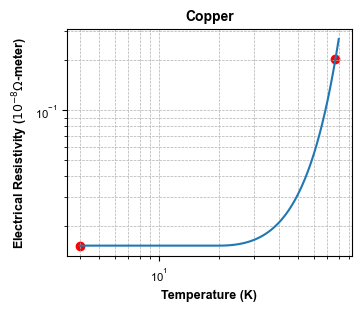

In [17]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)


# Similar to graph in (https://www.copper.org/resources/properties/cryogenic/)
ax.plot(T_range, rho_vals)
ax.scatter([4, 77], rho_data, color="red")
ax.set_xscale("log")
ax.set_yscale("log")
# --- enable both major and minor grid lines ---
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.set_title("Copper", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel(r'Electrical Resistivity ($10^{-8} \Omega$-meter)', fontproperties=axis_label_font)

for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)

plt.savefig(f"./cu_rho_4K-50K.png",dpi=600)
plt.show()

In [18]:
# Integrate and average
T_min, T_max = 4, 50
total_int, _ = quad(rho_func, T_min, T_max)
average_rho = total_int / (T_max - T_min) * 1E-8

print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Cu_4K = average_rho * l_4K / area
print(f"Average Resistance of {l_4K} meter 30 AWG Cu wire between 50K and 4K is {R_Cu_4K=:.3e} ohms")

Average Resistivity (4K-50K): 1.826600e-10 Ohm-m
Average Resistance of 0.29 meter 30 AWG Cu wire between 50K and 4K is R_Cu_4K=1.041e-03 ohms


# Electrical Resistivity (50K to 300K)

This can be assumed a linear relationship in log-log scale.

In [19]:
x_temp = np.array([50, 100, 200])
r_k = np.array([0.9E-2, 0.3, 1]) # 1E-8 ohm-meter

coefficients = np.polyfit(x_temp, r_k, 2)
y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0# + coefficients[3]

def resistivity_50K(x_temp):
    y_pred = coefficients[0]*x_temp**2 + coefficients[1]*x_temp**1 + coefficients[2]*x_temp**0# + coefficients[3]
    return y_pred

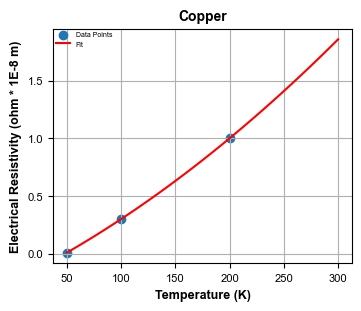

In [20]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

# Plotting the results
x_vals = np.linspace(50,300,100)
y_vals = resistivity_50K(x_vals)
ax.scatter(x_temp, r_k, label='Data Points')
ax.plot(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Copper", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Electrical Resistivity (ohm * 1E-8 m)', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    

ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./cu_rho_50K-300K.png",dpi=600)
plt.show()

In [21]:
# Integrate and average
T_min, T_max = 50, 300
total_int, _ = quad(resistivity_50K, T_min, T_max)
average_rho = total_int / (T_max - T_min) * 1E-8

print(f"Average Resistivity (4K-50K): {average_rho:.6e} Ohm-m")

R_Cu_50K = average_rho * l_50K / area
print(f"Average Resistance of {l_50K} meter 30 AWG Cu wire between 50K and 300K is {R_Cu_50K=:.3e} ohms")

Average Resistivity (4K-50K): 8.512222e-09 Ohm-m
Average Resistance of 0.2 meter 30 AWG Cu wire between 50K and 300K is R_Cu_50K=3.345e-02 ohms
